<a href="https://colab.research.google.com/github/capradhaan/ML_LinearRegression/blob/main/ML_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file = "Customer_Churn_CSV_Files.zip"
extract_folder = "churn_data"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

os.listdir(extract_folder)

['new_customers.csv', 'customer_churn.csv', 'data_dictionary.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("churn_data/customer_churn.csv")
new_df = pd.read_csv("churn_data/new_customers.csv")

df.head()


,customer_id,tenure,monthly_charges,total_charges,contract_type,payment_method,churn
0,1001,1,70,70,Month-to-month,Electronic check,1
1,1002,2,75,150,Month-to-month,Electronic check,1
2,1003,3,65,195,Month-to-month,Mailed check,1
3,1004,5,80,400,Month-to-month,Electronic check,1
4,1005,8,85,680,One year,Credit card,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['contract_type'] = le.fit_transform(df['contract_type'])
df['payment_method'] = le.fit_transform(df['payment_method'])

new_df['contract_type'] = le.fit_transform(new_df['contract_type'])
new_df['payment_method'] = le.fit_transform(new_df['payment_method'])


In [ ]:
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 0.3215151591389155
R2 Score: -1.009469744618222


In [ ]:
new_predictions = lr_model.predict(new_df)

new_df['Predicted_Churn_Value'] = new_predictions
new_df


,tenure,monthly_charges,total_charges,contract_type,payment_method,Predicted_Churn_Value
0,6,75,450,0,2,0.784581
1,18,95,1710,1,1,0.179316
2,2,65,130,0,3,1.047871
3,40,110,4400,2,0,-0.022065


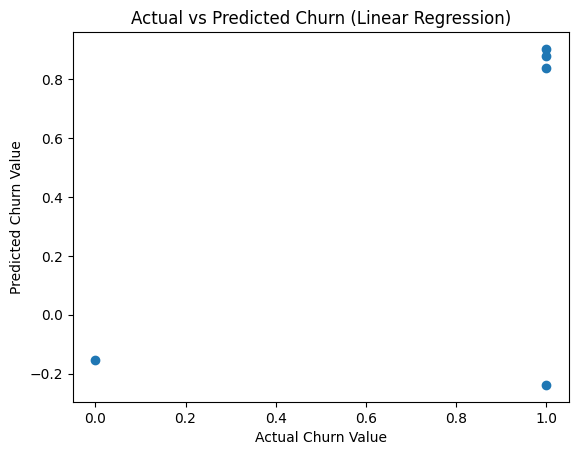

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Churn Value")
plt.ylabel("Predicted Churn Value")
plt.title("Actual vs Predicted Churn (Linear Regression)")
plt.show()


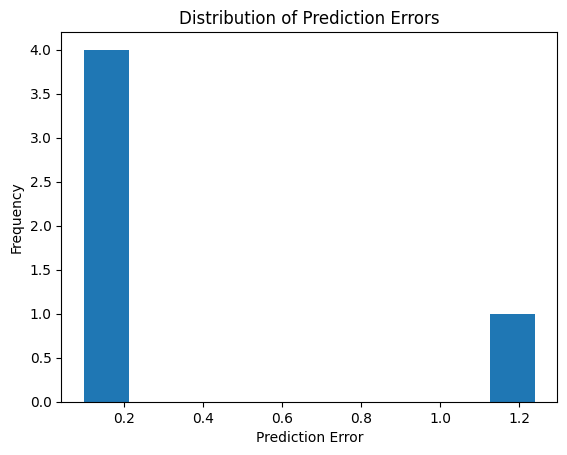

In [ ]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()
